In [1]:
import pandas as pd

In [19]:
ride_booking = pd.read_csv('ncr_ride_bookings.csv')

In [20]:
pd.set_option('display.max_colwidth', None)

In [21]:
ride_booking.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [22]:
ride_booking.shape

(150000, 21)

In [23]:
ride_booking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [24]:
ride_booking.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [30]:
ride_booking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [85]:
ride_booking['Booking Status'].unique()

array(['No Driver Found', 'Incomplete', 'Completed',
       'Cancelled by Driver', 'Cancelled by Customer'], dtype=object)

In [87]:
ride_booking['Booking Status'].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

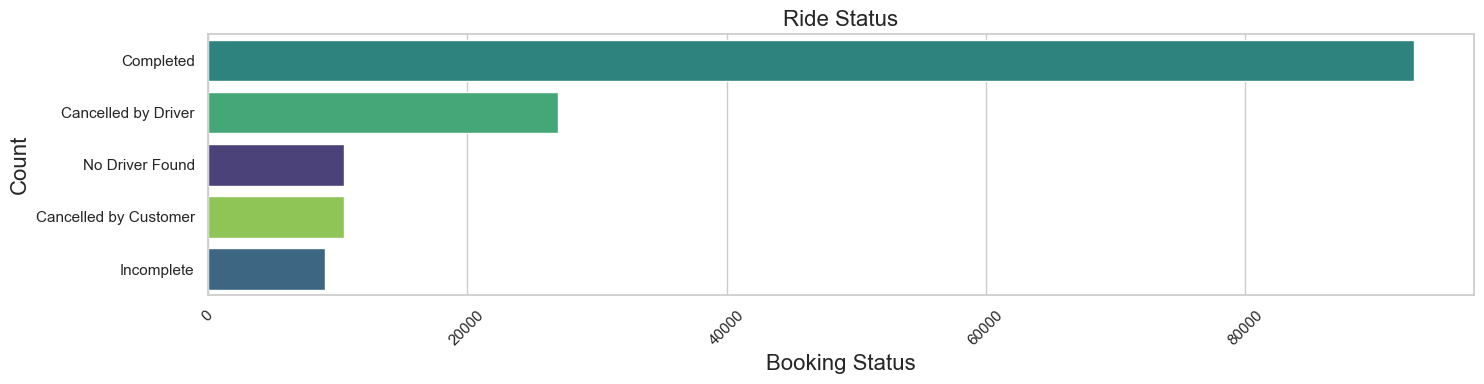

In [107]:
import seaborn as sns
sns.set_theme(style="whitegrid")

plt.figure(figsize=(15, 4))

ax = sns.countplot(data=ride_booking, y='Booking Status', hue='Booking Status', palette='viridis', 
                   order=ride_booking['Booking Status'].value_counts().index)

plt.title('Ride Status', fontsize=16)
plt.xlabel('Booking Status', fontsize=16)
plt.ylabel('Count', fontsize=16)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
ride_booking['Vehicle Type'].unique()

array(['eBike', 'Go Sedan', 'Auto', 'Premier Sedan', 'Bike', 'Go Mini',
       'Uber XL'], dtype=object)

In [27]:
 ride_booking['Reason for cancelling by Customer'].unique()

array([nan, 'Driver is not moving towards pickup location',
       'Driver asked to cancel', 'AC is not working', 'Change of plans',
       'Wrong Address'], dtype=object)

In [46]:
import matplotlib.pyplot as mp
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
ride_booking['Vehicle Type'].value_counts()

Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

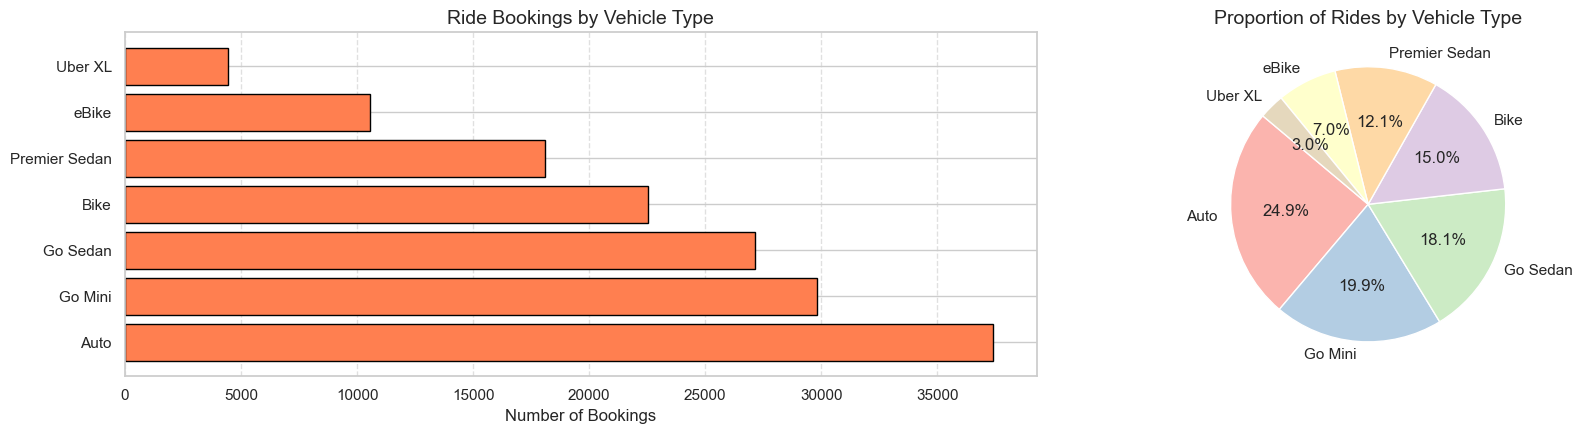

In [84]:
vehicle_count = ride_booking['Vehicle Type'].value_counts()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18.5, 4.5))

ax1.barh(vehicle_count.index, vehicle_count.values, color='coral', edgecolor='black')
ax1.set_title('Ride Bookings by Vehicle Type', fontsize=14)
ax1.set_xlabel('Number of Bookings')
ax1.grid(axis='x', linestyle='--', alpha=0.6)

ax2.pie(counts, labels=counts.index, autopct='%1.1f%%', 
        startangle=140, colors=plt.cm.Pastel1.colors)
ax2.set_title('Proportion of Rides by Vehicle Type', fontsize=14)

plt.tight_layout()
plt.show()

In [82]:
ride_booking['Pickup Location'].value_counts().head()

Pickup Location
Khandsa            949
Barakhamba Road    946
Saket              931
Badarpur           921
Pragati Maidan     920
Name: count, dtype: int64

In [83]:
ride_booking['Pickup Location'].value_counts().tail()

Pickup Location
Mandi House         800
Noida Sector 18     799
Laxmi Nagar         797
Ashok Vihar         796
Ghitorni Village    790
Name: count, dtype: int64

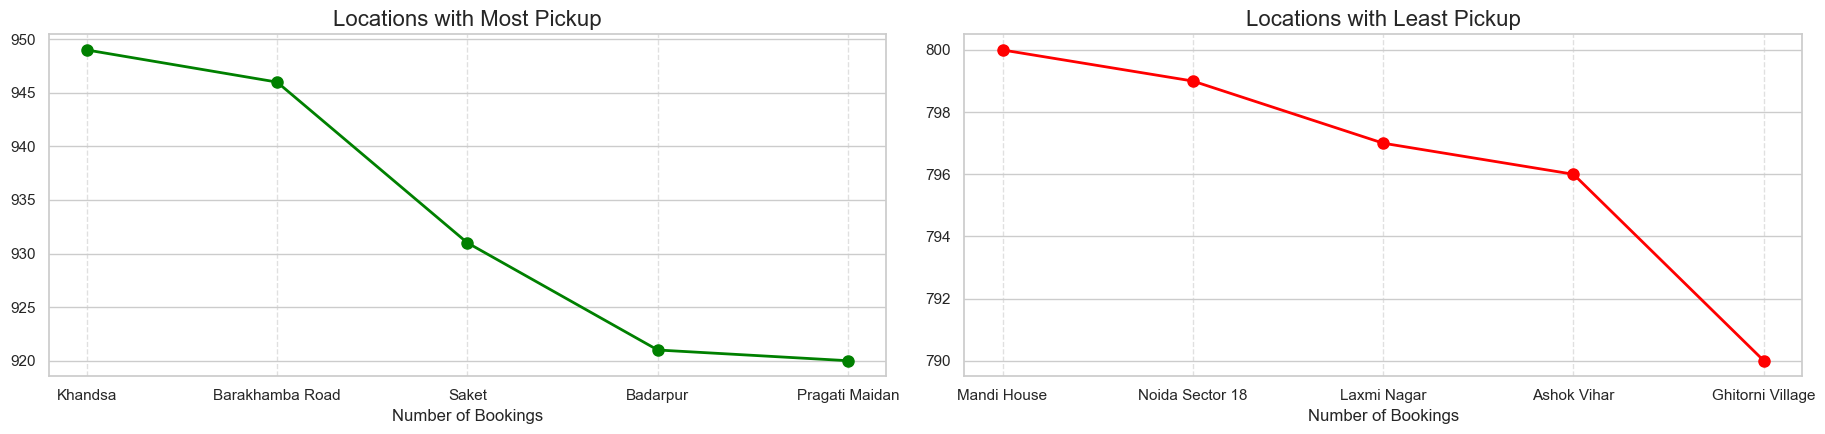

In [120]:
pickup_top = ride_booking['Pickup Location'].value_counts().head()
pickup_bottom = ride_booking['Pickup Location'].value_counts().tail()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18.5, 4.5))

ax1.plot(pickup_top.index, pickup_top.values, marker='o', linestyle='-', color='green', linewidth=2, markersize=8)
ax1.set_title('Locations with Most Pickup', fontsize=16)
ax1.set_xlabel('Number of Bookings')
ax1.grid(axis='x', linestyle='--', alpha=0.6)

ax2.plot(pickup_bottom.index, pickup_bottom.values, marker='o', linestyle='-', color='red', linewidth=2, markersize=8)
ax2.set_title('Locations with Least Pickup', fontsize=16)
ax2.set_xlabel('Number of Bookings')
ax2.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [117]:
ride_booking['Drop Location'].value_counts().head()

Drop Location
Ashram             936
Basai Dhankot      917
Lok Kalyan Marg    916
Narsinghpur        913
Cyber Hub          912
Name: count, dtype: int64

In [119]:
ride_booking['Drop Location'].value_counts().tail()

Drop Location
MG Road             799
Bhiwadi             792
Shivaji Park        786
Anand Vihar ISBT    784
Huda City Centre    774
Name: count, dtype: int64

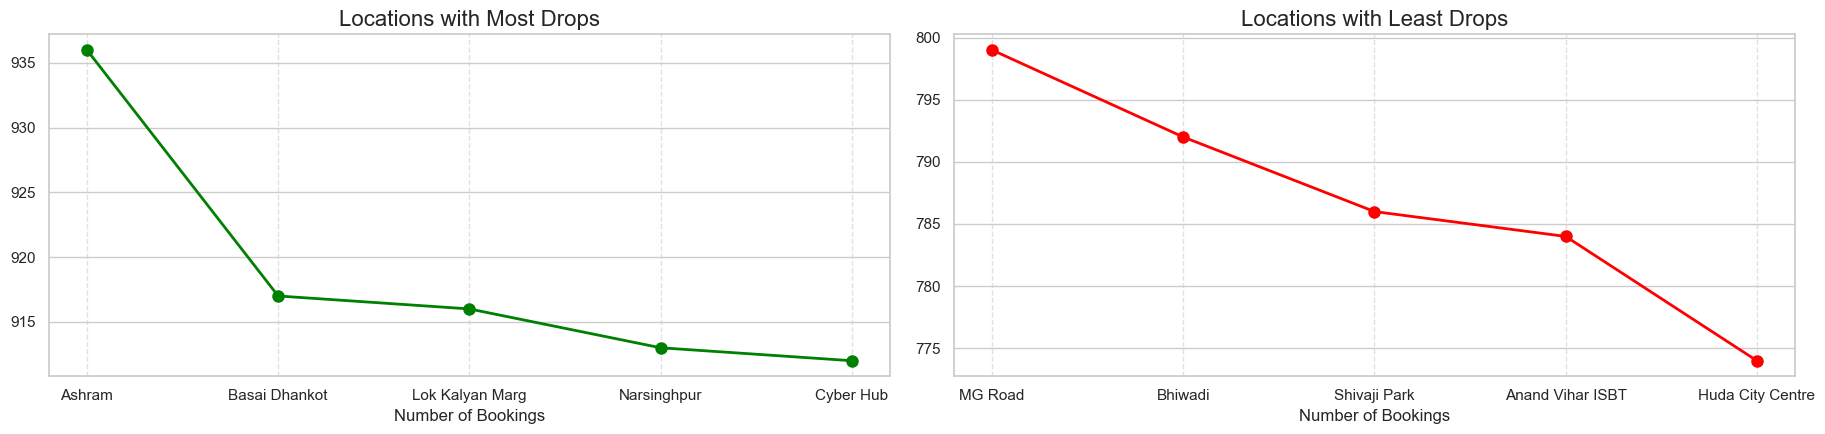

In [122]:
drop_top = ride_booking['Drop Location'].value_counts().head()
drop_bottom = ride_booking['Drop Location'].value_counts().tail()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18.5, 4.5))

ax1.plot(drop_top.index, drop_top.values, marker='o', linestyle='-', color='green', linewidth=2, markersize=8)
ax1.set_title('Locations with Most Drops', fontsize=16)
ax1.set_xlabel('Number of Bookings')
ax1.grid(axis='x', linestyle='--', alpha=0.6)

ax2.plot(drop_bottom.index, drop_bottom.values, marker='o', linestyle='-', color='red', linewidth=2, markersize=8)
ax2.set_title('Locations with Least Drops', fontsize=16)
ax2.set_xlabel('Number of Bookings')
ax2.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()